In [34]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Analyzing the probabilities after fine tuning

<b> We had different tests for the fine tuning outputs: </b>

- using different div factor (25), final div factor (20000) and max_lr of 1e-5 instead of 3e-4
- using original div factors (50), final div factor (10000) and max lr of 1e-5
- using the original div factors and max lr of 1e-5 but changing epoch values to n_epochs_freeze: 40 and n_epochs_unfreeze: 60

<b> First Scenario </b>

- add pretty high peaks and a validation loss that went in a concave down shape and went slightly above 2.5
- training loss had several peaks, the highest ones stayed at 3. downward trend

file name: mlm_tfenc_l6_h8_lr1e-5_uniref50viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-5_changeddivs_output.csv

In [35]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_tfenc_l6_h8_lr1e-5_uniref50viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-5_changeddivs_output.csv")
df1 = pd.read_csv(file_path)
df1

,Unnamed: 0,Cat,Chicken,European rabbit,Gray wolf,Human,Pig,y_true,itr
0,0,0.488431,0.119620,0.107170,0.164037,0.042756,0.077985,Human,0
1,1,0.006096,0.005043,0.057526,0.035703,0.736756,0.158875,Human,0
2,2,0.457689,0.114514,0.119851,0.176393,0.043528,0.088025,European rabbit,0
3,3,0.155254,0.037704,0.031280,0.165881,0.434863,0.175017,Human,0
4,4,0.367276,0.214597,0.094599,0.152804,0.044583,0.126141,Pig,0
5,5,0.476737,0.118777,0.118038,0.154226,0.041961,0.090261,Chicken,0
6,6,0.139878,0.197709,0.201787,0.096321,0.203780,0.160525,Human,0
7,7,0.275725,0.083988,0.255378,0.173927,0.102848,0.108135,Chicken,0
8,8,0.471984,0.107320,0.112929,0.169816,0.039518,0.098433,Cat,0
9,9,0.556103,0.110186,0.087611,0.140735,0.039593,0.065772,Gray wolf,0


<b> Second Scenario </b>

- validation loss peak did not go as high as first scenario, went slightly above 2
- training loss had similar peaks to the first one, but the highest peak went up to 5
  more downward trends for this scenario
- changes were not too significant, but noticeable, slightly better.
- This is why we kept the og div factors for new third scenario
  
file name: mlm_tfenc_l6_h8_lr1e-5pt2_uniref50viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-5_ogdiv_output.csv

In [36]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_tfenc_l6_h8_lr1e-5pt2_uniref50viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-5_ogdiv_output.csv")
df2 = pd.read_csv(file_path)
df2

,Unnamed: 0,Cat,Chicken,European rabbit,Gray wolf,Human,Pig,y_true,itr
0,0,0.088187,0.271152,0.102075,0.071075,0.401196,0.066314,Human,0
1,1,0.066186,0.290296,0.121944,0.096449,0.229588,0.195537,Human,0
2,2,0.336019,0.159752,0.182982,0.129978,0.098078,0.093191,Human,0
3,3,0.387805,0.171284,0.175168,0.117887,0.085982,0.061873,Cat,0
4,4,0.327489,0.300782,0.092682,0.075828,0.127570,0.075649,Chicken,0
5,5,0.015618,0.004327,0.101559,0.029578,0.472946,0.375973,Human,0
6,6,0.135524,0.524873,0.077390,0.060578,0.106022,0.095614,Chicken,0
7,7,0.282553,0.214373,0.198927,0.138442,0.070731,0.094974,Human,0
8,8,0.364214,0.176297,0.179731,0.102045,0.095680,0.082032,Chicken,0
9,9,0.116961,0.249136,0.178364,0.081980,0.178546,0.195012,Chicken,0


<b> Third Scenario </b>

- validation loss seemed worse here, has a slight upwards trend and peaks go up to 3
- this scenario has the best training loss. it peaks up to 5, but there is only one significant peak
- everything else about training loss is a nice downwards trend

file name: mlm_tfenc_l6_h8_lr1e-6_uniref50viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-5_changed_epochs_output.csv


<b> This scenario is a good example of overfitting. While the training loss looked the best here, the validation loss increased. This means overfitting. Maybe because there were more epochs so the model learned all of the data's flaws as well, learned it too well, so it could not predict the validation loss correctly </b>

In [37]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_tfenc_l6_h8_lr1e-6_uniref50viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-5_changed_epochs_output.csv")
df3 = pd.read_csv(file_path)
df3

,Unnamed: 0,Cat,Chicken,European rabbit,Gray wolf,Human,Pig,y_true,itr
0,0,0.412720,0.011013,0.031275,0.002056,0.389612,0.153323,Human,0
1,1,0.362624,0.183165,0.174434,0.231751,0.037420,0.010607,Chicken,0
2,2,0.477939,0.070878,0.186468,0.210256,0.045987,0.008472,European rabbit,0
3,3,0.494084,0.086449,0.152638,0.218776,0.040195,0.007859,Chicken,0
4,4,0.390423,0.260975,0.121642,0.149621,0.054064,0.023276,Pig,0
5,5,0.122762,0.389585,0.161531,0.127942,0.123373,0.074807,Human,0
6,6,0.633689,0.073781,0.097191,0.139924,0.047431,0.007984,Human,0
7,7,0.497602,0.076236,0.216027,0.142417,0.058193,0.009523,Chicken,0
8,8,0.077400,0.387162,0.265660,0.051248,0.160151,0.058378,Human,0
9,9,0.107136,0.247174,0.501241,0.043798,0.074604,0.026046,Chicken,0


In [38]:
human = df[df["y_true"] == "Human"]
human
#when it predicts human
#rows 14 (0.729), 18(0.578), 23(0.541)
#otherwise, it seems to commonly predict cat, rows 0, 6, 13, 15

cat = df[df["y_true"] == "Cat"]
cat
#Always accurately predicts cat!. but it is not completely sure

chicken = df[df["y_true"] == "Chicken"]
chicken
#Margin is pretty small, but seems to predict cat more than chicken: rows 1,3,7
#row 9 predicts wolf rabbit
#rows 16 & 22 predicts chicken correctly!
#2/6 times it predicts correctly

pig = df[df["y_true"] == "Pig"]
pig

wolf = df[df["y_true"] == "Gray wolf"]
wolf

rabbit = df[df["y_true"] == "European rabbit"]
rabbit

,Unnamed: 0,Cat,Chicken,European rabbit,Gray wolf,Human,Pig,y_true,itr,y_pred
15,15,0.389156,0.105231,0.142044,0.187863,0.065870,0.109836,European rabbit,0,Cat
33,6,0.162778,0.173316,0.272641,0.156498,0.094313,0.140453,European rabbit,1,European rabbit
79,25,0.044052,0.075061,0.529232,0.143871,0.175897,0.031888,European rabbit,2,European rabbit
98,17,0.080617,0.147791,0.283721,0.060763,0.018778,0.408331,European rabbit,3,Pig
120,12,0.214895,0.074798,0.292557,0.132966,0.079058,0.205726,European rabbit,4,European rabbit


# Most recent

In [39]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_tfenc_l6_h8_lr1e-6_uniref50viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-5_final_output.csv
")
df_final = pd.read_csv(file_path)
df_final

,Unnamed: 0,Cat,Chicken,European rabbit,Gray wolf,Human,Pig,y_true,itr
0,0,0.092565,0.154685,0.072600,0.173884,0.322611,0.183655,Human,0
1,1,0.413319,0.112904,0.113968,0.188249,0.064998,0.106563,Pig,0
2,2,0.492880,0.106734,0.093377,0.136344,0.080404,0.090262,Human,0
3,3,0.038249,0.136735,0.158560,0.180364,0.444808,0.041285,Human,0
4,4,0.099614,0.220222,0.065730,0.196319,0.233449,0.184666,Human,0
...,...,...,...,...,...,...,...,...,...
130,22,0.103008,0.164551,0.247137,0.027413,0.070135,0.387756,Chicken,4
131,23,0.015092,0.081642,0.101963,0.016482,0.541764,0.243057,Chicken,4
132,24,0.076392,0.624302,0.076234,0.035920,0.133933,0.053219,Human,4
133,25,0.025209,0.142712,0.335596,0.042261,0.386422,0.067800,Human,4


# Confusion Matrix

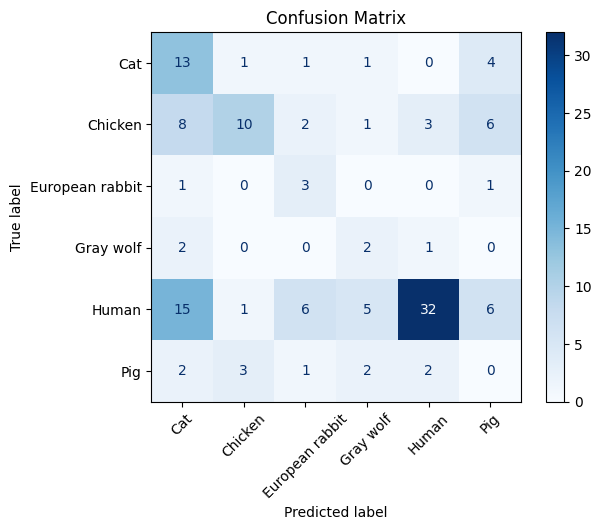

In [40]:
host_col = ['Cat', 'Chicken', 'European rabbit', 'Gray wolf', 'Human', 'Pig']
df_final['y_pred'] = df_final[host_col].idxmax(axis=1)

cm = confusion_matrix(df_final['y_true'], df_final['y_pred'], labels=host_col)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Analysis

- cat, chicken, and human are predicted pretty well. Although, the model often mixes up almost everything for cat.
- For pig, it was not predicted correct even once.
- Wolf was correct on two occurrences, but cat was also predicted for wolf twice.
- Human was misclassified as Cat 15 times, which is a lot.
- The model seems to be weak, and this can be seen in the validation loss graph.